## Data 

Retrieved from https://transtats.bts.gov/DL_SelectFields.aspx?gnoyr_VQ=FGJ&QO_fu146_anzr=b0-gvzr with the following columns selected:
* Quarter
* Month
* DayofMonth
* DayOfWeek
* Reporting_Airline
* OriginAirportID
* Origin
* OriginCityName
* DestAirportID
* Dest
* DestCityName
* CRSDepTime
* CRSArrTime
* ArrDel15
* CRSElapsedTime
* Distance
  

## Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Import Data

In [2]:
df = pd.read_csv("../data/raw/flights_2026_01_full.csv")

In [3]:
df.head()

,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST_AIRPORT_ID,DEST,DEST_CITY_NAME,CRS_DEP_TIME,CRS_ARR_TIME,ARR_DEL15,CRS_ELAPSED_TIME,DISTANCE
0,1,1,1,4,AA,10140,ABQ,"Albuquerque, NM",11298,DFW,"Dallas/Fort Worth, TX",600,902,0.0,122.0,569.0
1,1,1,1,4,AA,10140,ABQ,"Albuquerque, NM",11298,DFW,"Dallas/Fort Worth, TX",819,1121,0.0,122.0,569.0
2,1,1,1,4,AA,10140,ABQ,"Albuquerque, NM",11298,DFW,"Dallas/Fort Worth, TX",1030,1330,1.0,120.0,569.0
3,1,1,1,4,AA,10140,ABQ,"Albuquerque, NM",11298,DFW,"Dallas/Fort Worth, TX",1238,1538,0.0,120.0,569.0
4,1,1,1,4,AA,10140,ABQ,"Albuquerque, NM",11298,DFW,"Dallas/Fort Worth, TX",1656,2000,1.0,124.0,569.0


In [15]:
airports = list(set(list(df["ORIGIN"].unique()) + list(df["DEST"].unique())))

airports = pd.Series(airports, name="airport")

#airports.to_csv("airports")
airports

0      TOL
1      DHN
2      AZA
3      SIT
4      CWA
      ... 
337    LNK
338    TWF
339    DTW
340    GRI
341    LBL
Name: airport, Length: 342, dtype: object

## Cleaning

In [4]:
df[df.duplicated()]

,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST_AIRPORT_ID,DEST,DEST_CITY_NAME,CRS_DEP_TIME,CRS_ARR_TIME,ARR_DEL15,CRS_ELAPSED_TIME,DISTANCE
179900,1,1,10,6,YX,10721,BOS,"Boston, MA",12478,JFK,"New York, NY",1005,1129,0.0,84.0,187.0
180338,1,1,10,6,YX,12953,LGA,"New York, NY",13930,ORD,"Chicago, IL",1030,1225,0.0,175.0,733.0
301274,1,1,17,6,YX,10721,BOS,"Boston, MA",12478,JFK,"New York, NY",1005,1129,0.0,84.0,187.0
301710,1,1,17,6,YX,12953,LGA,"New York, NY",13930,ORD,"Chicago, IL",1030,1225,0.0,175.0,733.0
421988,1,1,24,6,YX,10721,BOS,"Boston, MA",12478,JFK,"New York, NY",1005,1129,0.0,84.0,187.0
422429,1,1,24,6,YX,12953,LGA,"New York, NY",13930,ORD,"Chicago, IL",1030,1225,0.0,175.0,733.0
543258,1,1,31,6,YX,10721,BOS,"Boston, MA",12478,JFK,"New York, NY",1005,1129,0.0,84.0,187.0


* There are a few duplicates which will need to be dropped in the pipeline

In [5]:
df = df.drop_duplicates()

In [6]:
df.isna().sum()

QUARTER                  0
MONTH                    0
DAY_OF_MONTH             0
DAY_OF_WEEK              0
OP_UNIQUE_CARRIER        0
ORIGIN_AIRPORT_ID        0
ORIGIN                   0
ORIGIN_CITY_NAME         0
DEST_AIRPORT_ID          0
DEST                     0
DEST_CITY_NAME           0
CRS_DEP_TIME             0
CRS_ARR_TIME             0
ARR_DEL15            26781
CRS_ELAPSED_TIME         0
DISTANCE                 0
dtype: int64

In [7]:
df = df.dropna(subset='ARR_DEL15')

* Unfortunately there are many missing delays which will need to be dropped

In [27]:
df.dtypes

QUARTER                int64
MONTH                  int64
DAY_OF_MONTH           int64
DAY_OF_WEEK            int64
ORIGIN_AIRPORT_ID      int64
ORIGIN                   str
ORIGIN_CITY_NAME         str
DEST_AIRPORT_ID        int64
DEST                     str
DEST_CITY_NAME           str
CRS_DEP_TIME           int64
CRS_ARR_TIME           int64
ARR_DEL15            float64
CRS_ELAPSED_TIME     float64
DISTANCE             float64
AIRLINE                  str
dtype: object

* All data types make sense

## Independent Variables

### OP_UNIQUE_CARRIER

In [8]:
df['OP_UNIQUE_CARRIER'].value_counts()

OP_UNIQUE_CARRIER
WN    101120
DL     75939
AA     69740
OO     63708
UA     62176
YX     27105
AS     25799
MQ     22926
OH     17247
B6     16875
F9     14817
NK     11047
G4      8716
Name: count, dtype: int64

* Let's use the lookup table to convert the carrier into a understandable name

In [9]:
carriers = pd.read_csv("../data/raw/carrier_lookup_table.csv")

In [10]:
carriers.head()

,Code,Description
0,02Q,Titan Airways
1,05Q,"Comlux Aviation, AG"
2,06Q,Master Top Linhas Aereas Ltd.
3,07Q,Flair Airlines Ltd.
4,09Q,"Swift Air, LLC d/b/a Eastern Air Lines d/b/a E..."


In [11]:
df = df.merge(carriers, left_on='OP_UNIQUE_CARRIER', right_on='Code', how='left')

In [12]:
df[['OP_UNIQUE_CARRIER','Code']].isnull().sum()

OP_UNIQUE_CARRIER    0
Code                 0
dtype: int64

* Merge was successful

In [13]:
df['AIRLINE'] = df['Description']
df = df.drop(['OP_UNIQUE_CARRIER','Code','Description'], axis=1)

* Drop unneeded columns

In [28]:
df['AIRLINE'].value_counts()

AIRLINE
Southwest Airlines Co.    101120
Delta Air Lines Inc.       75939
American Airlines Inc.     69740
SkyWest Airlines Inc.      63708
United Air Lines Inc.      62176
Republic Airline           27105
Alaska Airlines Inc.       25799
Envoy Air                  22926
PSA Airlines Inc.          17247
JetBlue Airways            16875
Frontier Airlines Inc.     14817
Spirit Air Lines           11047
Allegiant Air               8716
Name: count, dtype: int64

### DEST AND ORIGIN

In [14]:
len(df['ORIGIN_AIRPORT_ID'].unique()),len(df['ORIGIN'].unique()), len(df['ORIGIN_CITY_NAME'].unique())

(341, 341, 335)

In [15]:
len(df['DEST_AIRPORT_ID'].unique()),len(df['DEST'].unique()), len(df['DEST_CITY_NAME'].unique())

(341, 341, 335)

* City name will be very helpful for future weather data but it is not the same as origin
* For now keep origin city name in the raw data but drop for now in the processed

## CRS_DEP_TIME and CRS_ARR_TIME

In [16]:
df['CRS_DEP_TIME'].describe().astype(int)

count    517215
mean       1312
std         476
min           2
25%         905
50%        1310
75%        1718
max        2359
Name: CRS_DEP_TIME, dtype: int64

In [17]:
df['CRS_ARR_TIME'].describe().astype(int)

count    517215
mean       1507
std         494
min           1
25%        1120
50%        1525
75%        1920
max        2359
Name: CRS_ARR_TIME, dtype: int64

In [18]:
df['CRS_ELAPSED_TIME'].describe().astype(int)

count    517215
mean        152
std          74
min          25
25%          98
50%         137
75%         185
max        1202
Name: CRS_ELAPSED_TIME, dtype: int64

In [19]:
df['DISTANCE'].describe().astype(int)

count    517215
mean        848
std         605
min          31
25%         404
50%         707
75%        1085
max        4983
Name: DISTANCE, dtype: int64

* All numerical columns appear normal with reasonable minium and maximum values

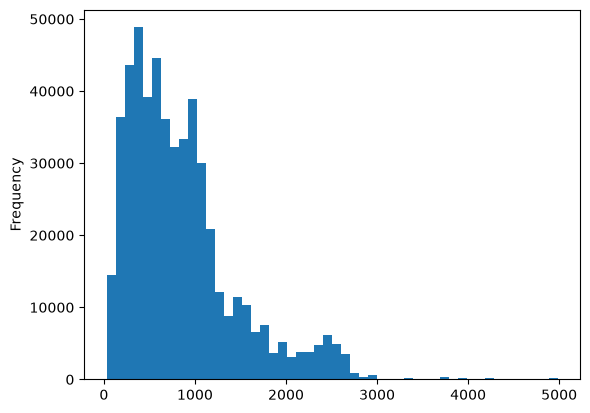

In [20]:
df['DISTANCE'].plot(kind='hist',bins=50);

In [29]:
df.sort_values('DISTANCE', ascending=False).head(3)

,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST_AIRPORT_ID,DEST,DEST_CITY_NAME,CRS_DEP_TIME,CRS_ARR_TIME,ARR_DEL15,CRS_ELAPSED_TIME,DISTANCE,AIRLINE
491173,1,1,30,5,12173,HNL,"Honolulu, HI",12478,JFK,"New York, NY",1755,845,0.0,590.0,4983.0,Delta Air Lines Inc.
390528,1,1,23,5,12173,HNL,"Honolulu, HI",12478,JFK,"New York, NY",1755,845,0.0,590.0,4983.0,Delta Air Lines Inc.
167607,1,1,10,6,12478,JFK,"New York, NY",12173,HNL,"Honolulu, HI",1005,1628,0.0,683.0,4983.0,Delta Air Lines Inc.


## Flight Delay

In [22]:
df['ARR_DEL15'].astype(bool).value_counts()

ARR_DEL15
False    409740
True     107475
Name: count, dtype: int64

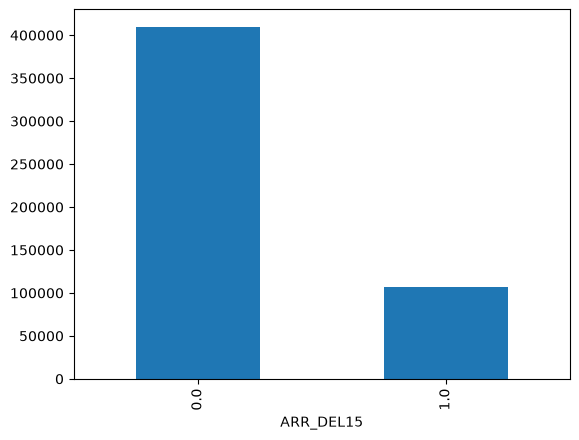

In [26]:
df['ARR_DEL15'].value_counts().plot(kind='bar');

## Correlations

In [24]:
df.corr(numeric_only=True).drop(['QUARTER', 'MONTH'], axis=1).drop(['QUARTER', 'MONTH']).round(2)

,DAY_OF_MONTH,DAY_OF_WEEK,ORIGIN_AIRPORT_ID,DEST_AIRPORT_ID,CRS_DEP_TIME,CRS_ARR_TIME,ARR_DEL15,CRS_ELAPSED_TIME,DISTANCE
DAY_OF_MONTH,1.00,-0.05,0.01,0.01,-0.02,0.01,0.02,-0.01,-0.02
DAY_OF_WEEK,-0.05,1.00,0.01,0.01,-0.00,-0.01,0.05,0.01,0.02
ORIGIN_AIRPORT_ID,0.01,0.01,1.00,0.00,-0.04,-0.01,-0.02,0.05,0.07
DEST_AIRPORT_ID,0.01,0.01,0.00,1.00,0.03,0.03,0.01,0.09,0.07
CRS_DEP_TIME,-0.02,-0.00,-0.04,0.03,1.00,0.74,0.10,-0.04,-0.02
CRS_ARR_TIME,0.01,-0.01,-0.01,0.03,0.74,1.00,0.09,0.03,0.04
ARR_DEL15,0.02,0.05,-0.02,0.01,0.10,0.09,1.00,0.02,0.01
CRS_ELAPSED_TIME,-0.01,0.01,0.05,0.09,-0.04,0.03,0.02,1.00,0.98
DISTANCE,-0.02,0.02,0.07,0.07,-0.02,0.04,0.01,0.98,1.00


* For the numeric columns there is not strong linear correlation with delays